##### Inital settings and import dependecies

In [11]:
import sys
import os
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
import pytorch_lightning as pl
import numpy as np
import random
import shap
from tqdm import tqdm
import matplotlib.pyplot as plt


# Add the 'training' directory to sys.path
sys.path.append(os.path.abspath("training"))
from training_utils import CNN2D, SpectraDataset_s, SpectraDataset_p, spectra_stats

In [12]:
# Set a fixed seed value
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
pl.seed_everything(SEED)
print("Seed has been set")

Seed set to 42


Seed has been set


In [13]:
# Path to the data
data_path_64 = "preprocessed_dset/sp_64"
data_path_32 = "preprocessed_dset/sp_32"
meta_path = "preprocessed_dset/features_and_metadata.csv"

data_path_64_p = os.path.join(data_path_64, "explainer_p_wave")
data_path_32_p = os.path.join(data_path_32, "explainer_p_wave")
data_path_64_s = os.path.join(data_path_64, "explainer_s_wave")
data_path_32_s = os.path.join(data_path_32, "explainer_s_wave")

f_t_range_64_path = os.path.join(data_path_64, "f_t_range.npy")
f_t_range_32_path = os.path.join(data_path_32, "f_t_range.npy")
tf64, tf32 = np.load(f_t_range_64_path), np.load(f_t_range_32_path)
f64, t64 = tf64[:2], tf64[2:]
f32, t32 = tf32[:2], tf32[2:]


# Path to the best model found in the training notebooks
best_model_p_64 = "training/p_wave_model_checkpoints/model_checkpoints_64/best_model_fold_s.ckpt"
best_model_p_32 = "training/p_wave_model_checkpoints/model_checkpoints_32/best_model_fold.ckpt"
best_model_s_64 = "training/s_wave_model_checkpoints/model_checkpoints_64/best_model_fold_s.ckpt"
best_model_s_32 = "training/s_wave_model_checkpoints/model_checkpoints_32/best_model_fold_s.ckpt"

dim_p64 = (33, 188)
dim_p32 = (17, 155)
dim_s64 = (33, 150)
dim_s32 = (17, 124)

# Setting for the datasets
mean_64, std_64 = spectra_stats(os.path.join(data_path_64, "train"))
mean_32, std_32 = spectra_stats(os.path.join(data_path_32, "train"))

transform_64 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_64, std=std_64)
])

transform_32 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_32, std=std_32)
])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

(preprocessed_dset/sp_64\train) Mean: [0.67176665 0.65817659 0.6412554 ], Std: [0.1186761  0.12021562 0.11939131] (calculated and saved)
(preprocessed_dset/sp_32\train) Mean: [0.65032865 0.63513704 0.61763785], Std: [0.12265336 0.12450042 0.12385332] (calculated and saved)


In [14]:
def prepare_image_for_plot(image, spec_type):
    # Converte il tensore PyTorch in un array NumPy
    if spec_type[-2:] == "64":
        mean = mean_64
        std = std_64
    elif spec_type[-2:] == "32":
        mean = mean_32
        std = std_32
    else:
        raise ValueError("Invalid spec_type")
    
    if isinstance(image, torch.Tensor):
        image = image.cpu().numpy()
        
    return (np.clip(image.transpose(1,2,0) * std + mean, 0, 1) * 255).astype(np.uint8)

# Function to preprocess input for the model
def preprocess_for_shap(images):
    # Normalize to [0, 1] using torch functions
    min_val = torch.min(images)
    max_val = torch.max(images)
    shap_images = (images - min_val) / (max_val - min_val)
    
    # Scale to [0, 255] and convert to uint8
    shap_images = (shap_images * 255).to(torch.uint8)
    
    # Convert from (batch_size, 3, 33, 153) to (batch_size, 33, 153, 3)
    shap_images = shap_images.permute(0, 2, 3, 1)
    
    return shap_images, min_val.item(), max_val.item()

def inverse_preprocess_for_shap(shap_images, original_min, original_max):
    # Convert from (batch_size, 33, 153, 3) to (batch_size, 3, 33, 153)
    shap_images = shap_images.permute(0, 3, 1, 2)
    
    # Scale from [0, 255] to [0, 1]
    shap_images = shap_images / 255.0
    
    # Rescale to the original range [original_min, original_max]
    shap_images = shap_images * (original_max - original_min) + original_min
    
    return shap_images

In [15]:
def compute_shap_tensor(model, sample, dim, max_evals=1000, masker_settings="inpaint_telea"):

    images, _, _ = sample

    def model_fn(images):
        # Convert from NumPy array to PyTorch tensor if needed
        if isinstance(images, np.ndarray):
            images = torch.from_numpy(images).float()
        
        # Ensure the images are moved to the correct device
        images = images.to(device)
        
        # Perform inverse preprocessing for SHAP
        images = inverse_preprocess_for_shap(images, original_min, original_max)
        
        # Pass the images through the model
        outputs = model(images)
        
        # Return the outputs as NumPy array
        return outputs.cpu().detach().numpy()

    images_to_explain, original_min, original_max = preprocess_for_shap(images)
    masker = shap.maskers.Image(masker_settings, (*dim, 3))
    explainer = shap.Explainer(model_fn, masker, output_names=["Foreshock", "Aftershock"])

    shap_values = explainer(
        images_to_explain,
        max_evals=max_evals,
        batch_size=50,
        outputs=shap.Explanation.argsort.flip[:1]
        )
    
    return np.array(shap_values.values).squeeze(axis=-1)

def compute_mean_shap_tensor(model, dloader, dim, max_evals = 1000, masker_settings = "inpaint_telea", save_path = None):
    
    tot = len(dloader)
    mean_shap_tensor = np.zeros((*dim, 3))

    for sample in tqdm(dloader, desc = "Computing Mean SHAP Tensor", total = tot):
        mean_shap_tensor += np.mean(compute_shap_tensor(model, sample, dim, max_evals, masker_settings), axis=0)/tot

    if save_path:
        np.save(save_path, mean_shap_tensor)

    return mean_shap_tensor
    


In [16]:
def plot_shap(shap_tensor, onechannel, background, label=None, name=None, model_output=None, spec_type="p64", mean = False, figsize=(15, 7)):
    f, t = (f64, t64) if spec_type[-2:] else (f32, t32)
    if spec_type[0] == 's':
        t = (0,20)
    if onechannel:
        grayscale_shap_tensor = np.mean(shap_tensor, axis=-1)
        plt.figure(figsize=figsize)
        plt.xlabel('Time [s]')
        plt.ylabel('Frequency [Hz]')
        plt.axvline(5, c='black', label = f'{spec_type[0]}-wave arrival')
        if background != None:
            bg_image = prepare_image_for_plot(background, spec_type)
            plt.imshow(
                        bg_image, 
                        aspect='auto', 
                        origin='lower', 
                        extent=[*t, *f]
                        )
        im = plt.imshow(
                        grayscale_shap_tensor, 
                        cmap="coolwarm", 
                        alpha=np.abs(grayscale_shap_tensor)/np.max(np.abs(grayscale_shap_tensor)), 
                        aspect='auto', 
                        origin='lower', 
                        extent=[*t, *f]
                        )
        cbar = plt.colorbar(im, orientation="horizontal", pad=0.1)
        cbar.set_label("Contribution to the prediction")
        plt.legend()
        if not mean:
            plt.title(f"SHAP on 1-channel mean ({name})\n Model output: {model_output.cpu().detach().numpy()} --> Label: {'Aftershock' if label else 'Foreshock'}")
        else:
            plt.title(mean)
        plt.show()

    if not onechannel:
        fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True)
        if not mean:
            plt.suptitle(f"SHAP on the three components ({name})\n Model output: {model_output.cpu().detach().numpy()} --> Label: {'Aftershock' if label else 'Foreshock'}")
        else:
            plt.suptitle(mean)
        for i in range(3):
            if background != None:
                bg_image = prepare_image_for_plot(background, spec_type)
                axes[i].imshow(
                                bg_image[:,:,i],  # Ensure correct shape
                                cmap="gray",
                                aspect="auto",
                                origin="lower",
                                extent=[*t, *f],
                            )
            im = axes[i].imshow(
                                shap_tensor[:,:,i],
                                cmap = "coolwarm",
                                alpha = np.abs(shap_tensor[:,:,i])/np.max(np.abs(shap_tensor)),
                                aspect = "auto",
                                origin = "lower",
                                extent = [*t, *f]
                                )
            axes[i].set_ylabel("Freuqency (Hz)")
            axes[i].axvline(5, c='black', label=f'{spec_type[0]}-wave arrival')
            axes[i].set_yticks(np.linspace(*f, num=6))  # Adjust number of ticks as needed
            axes[i].set_yticklabels([f"{freq:.1f}" for freq in np.linspace(*f, num=6)])  # Format frequency labels

        plt.colorbar(im, ax = axes, orientation='vertical', label="Contribution to the prediction")
        axes[0].legend(loc="upper right")
        axes[-1].set_xlabel("Time (s)")

## Explainability on P-Wave fixed Spectrograms

### Spectra64 Settings 
$
\textbf{NPERSEG} = 64
$

$
\textbf{NOVERLAP} = \textbf{NPERSEG} * 0.8
$

In [17]:
model = CNN2D.load_from_checkpoint(best_model_p_64, input_dim=dim_p64, num_classes=2)
model.eval()
model.to(device)
print("Model loaded")

Model loaded


#### Foreshocks

In [18]:
dset_pre = SpectraDataset_p(os.path.join(data_path_64_p, "foreshock"), transform=transform_64, get_image_name=True)
dloader_pre = DataLoader(dset_pre, batch_size=30, shuffle=False)

PartitionExplainer explainer: 2it [00:53, 53.40s/it]               
PartitionExplainer explainer: 2it [01:09, 69.09s/it]               


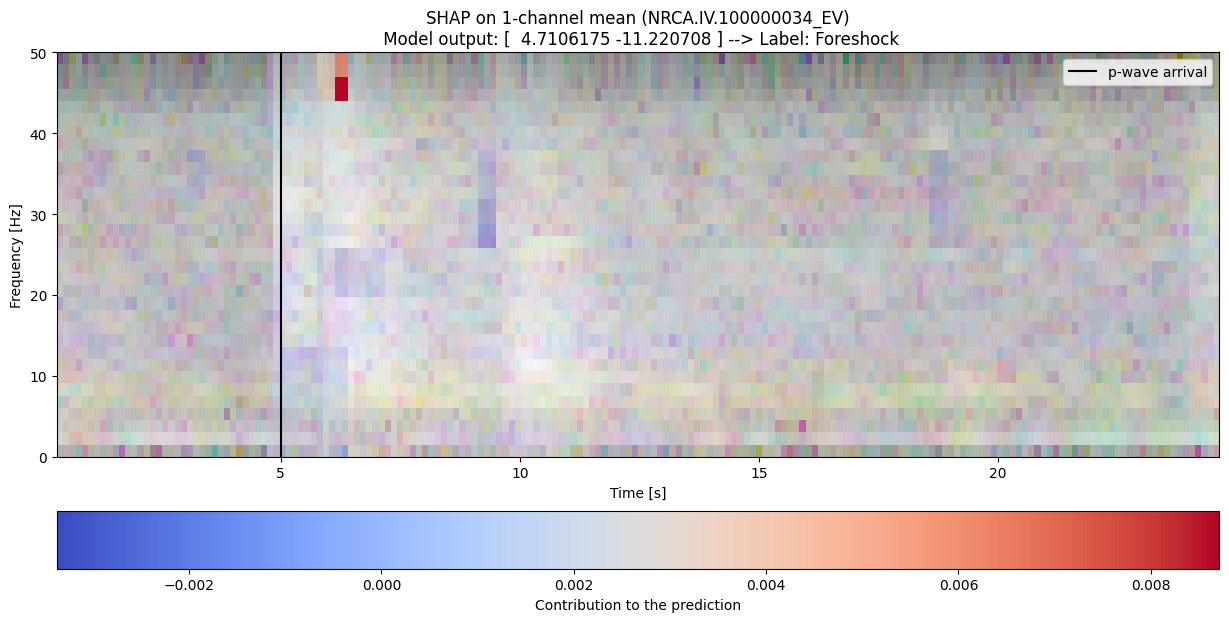

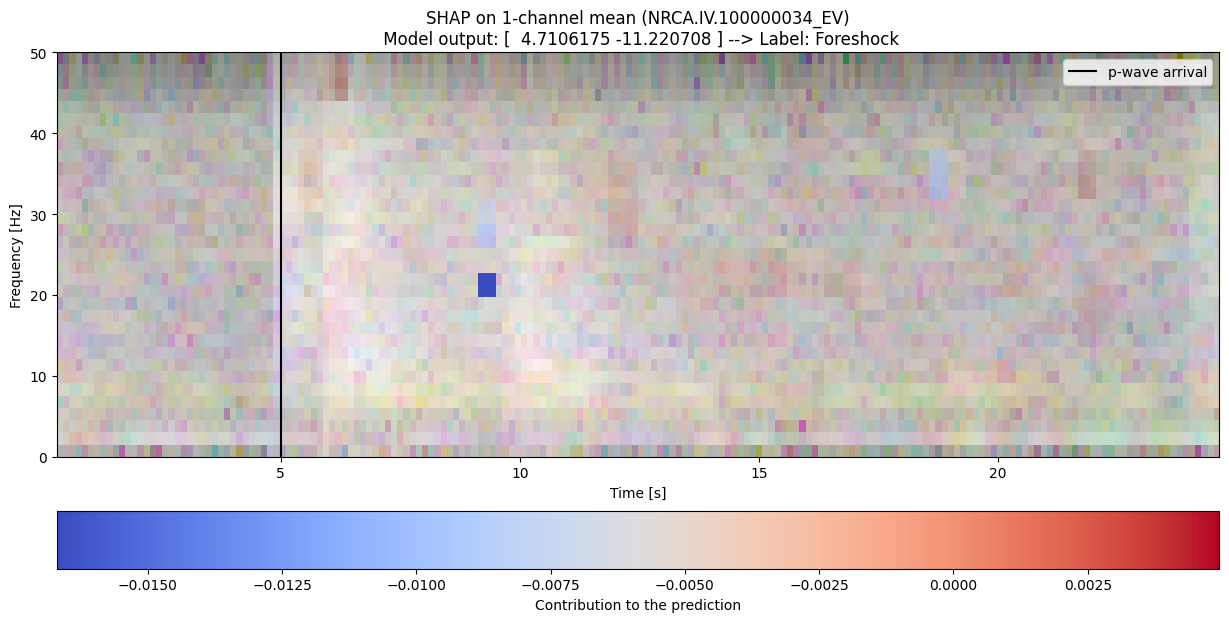

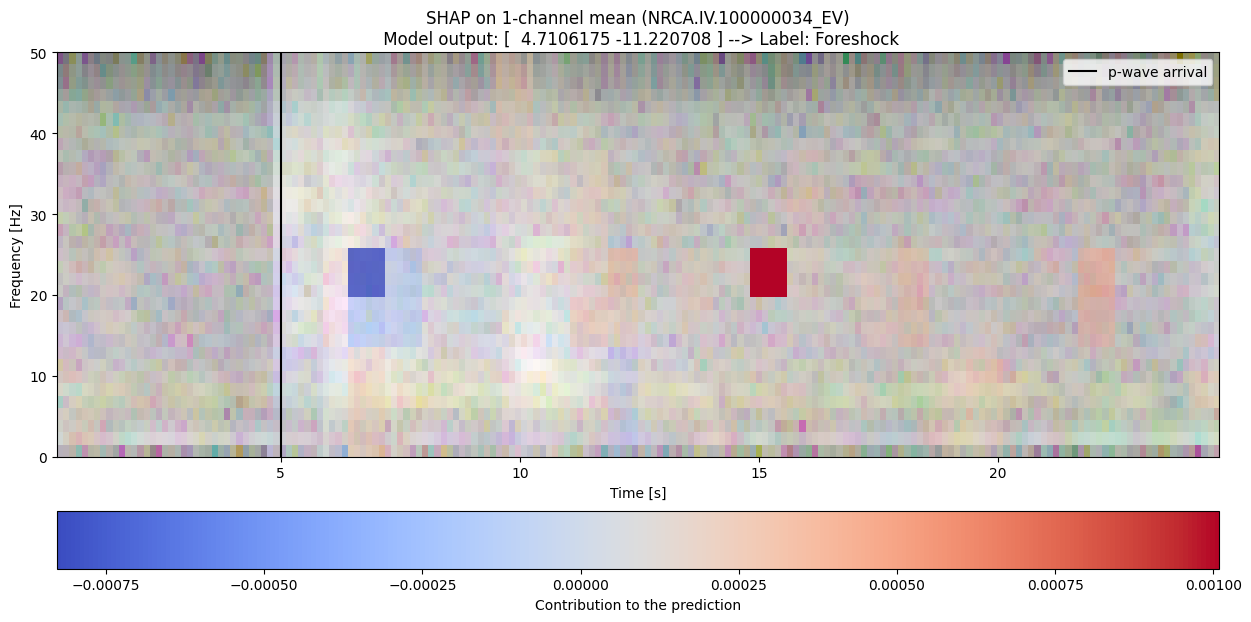

In [30]:
# SHAP Example on 1 sample
example_dataloader = DataLoader(dset_pre, batch_size=1, shuffle=False)
example_iter = next(iter(example_dataloader))

example_images, labels, names = example_iter
model_outputs = model(example_images.to(device))

example_p64_pre_1 = compute_shap_tensor(model, example_iter, dim_p64, max_evals=5000)
example_p64_pre_2 = compute_shap_tensor(model, example_iter, dim_p64, max_evals=5000, masker_settings="inpaint_ns")
example_p64_pre_3 = compute_shap_tensor(model, example_iter, dim_p64, max_evals=5000, masker_settings="blur(3, 3)")

plot_shap(example_p64_pre_1[0], onechannel=True, background=example_images[0], label=labels[0], name=names[0], model_output=model_outputs[0], spec_type="p64", figsize=(15, 7))
plot_shap(example_p64_pre_2[0], onechannel=True, background=example_images[0], label=labels[0], name=names[0], model_output=model_outputs[0], spec_type="p64", figsize=(15, 7))
plot_shap(example_p64_pre_3[0], onechannel=True, background=example_images[0], label=labels[0], name=names[0], model_output=model_outputs[0], spec_type="p64", figsize=(15, 7))

In [98]:
mean_shap_tensor = compute_mean_shap_tensor(model, dloader_pre, dim_p64, max_evals = 10, masker_settings = "inpaint_telea", save_path = None)

Computing Mean SHAP Tensor: 100%|██████████| 10/10 [00:43<00:00,  4.34s/it]


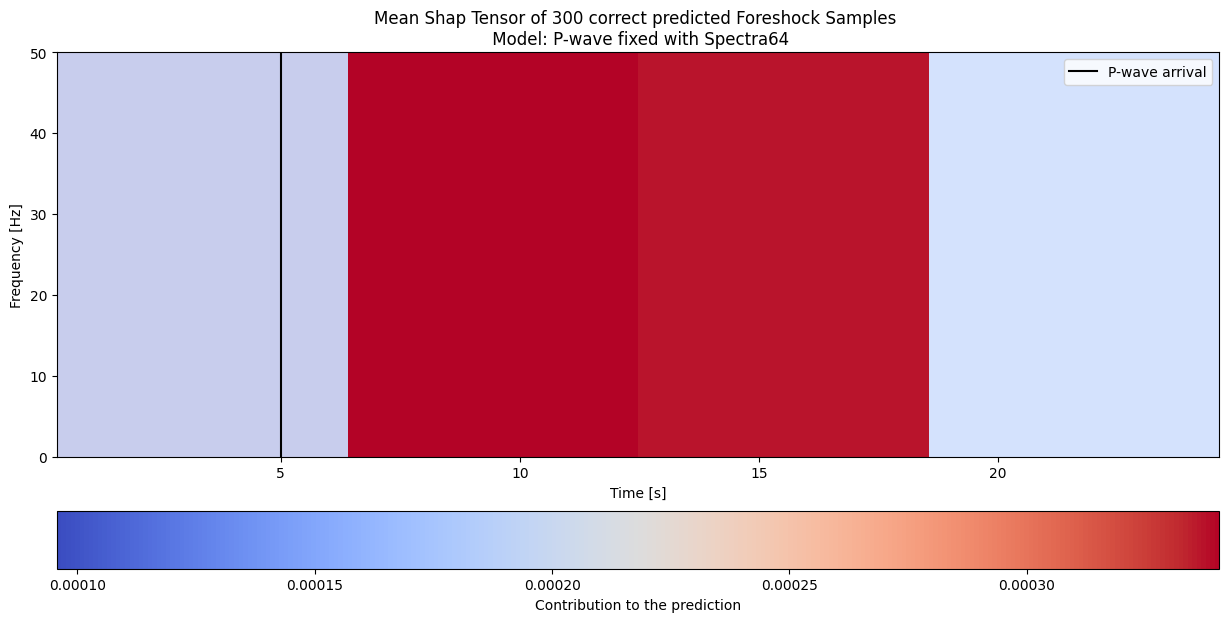

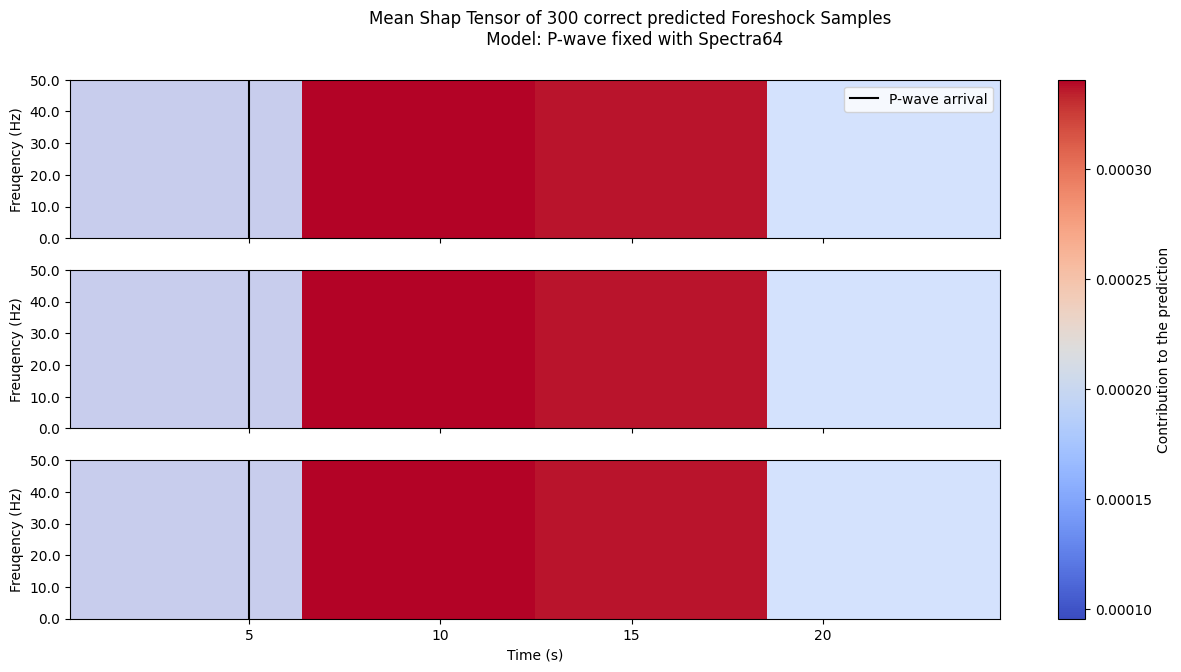

In [99]:
plot_shap(mean_shap_tensor, onechannel=True, background=None, spec_type="p64", mean=f"Mean Shap Tensor of 300 correct predicted Foreshock Samples \n Model: P-wave fixed with Spectra64")
plot_shap(mean_shap_tensor, onechannel=False, background=None, spec_type="p64", mean=f"Mean Shap Tensor of 300 correct predicted Foreshock Samples \n Model: P-wave fixed with Spectra64")

#### Aftershocks

In [100]:
dset_post = SpectraDataset_p(os.path.join(data_path_64_p, "aftershock"), transform=transform_64, get_image_name=True)
dloader_post = DataLoader(dset_post, batch_size=30, shuffle=False)

In [101]:
mean_shap_tensor = compute_mean_shap_tensor(model, dloader_post, dim_p64, max_evals = 10, masker_settings = "inpaint_telea", save_path = None)

Computing Mean SHAP Tensor: 100%|██████████| 10/10 [00:46<00:00,  4.69s/it]


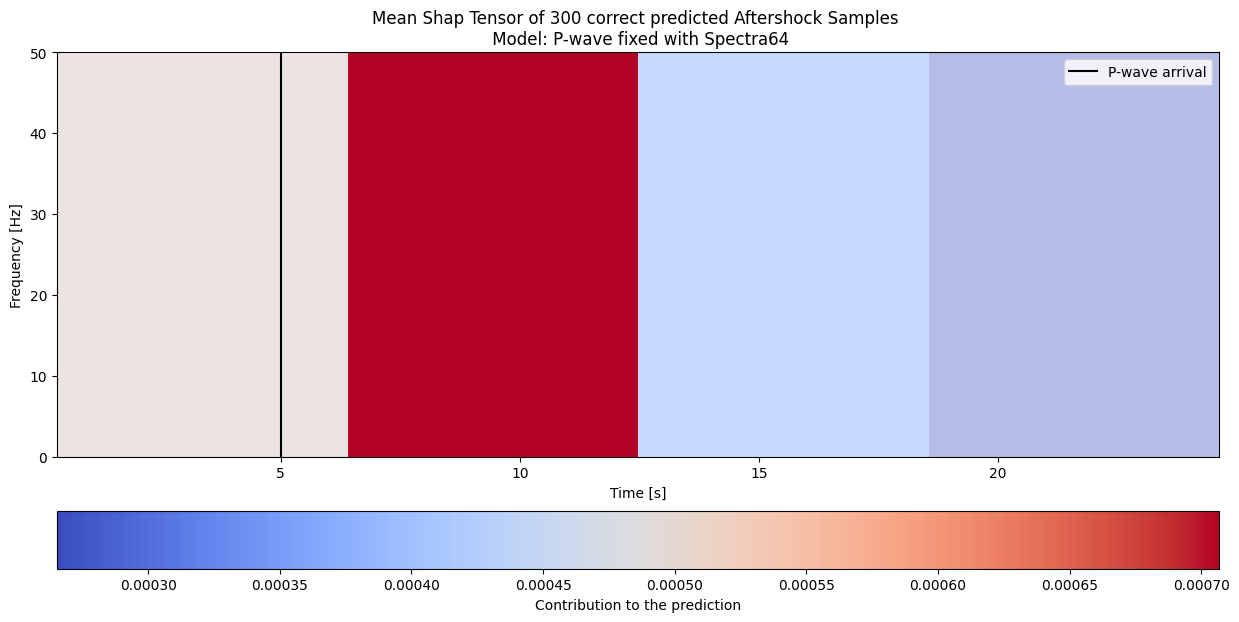

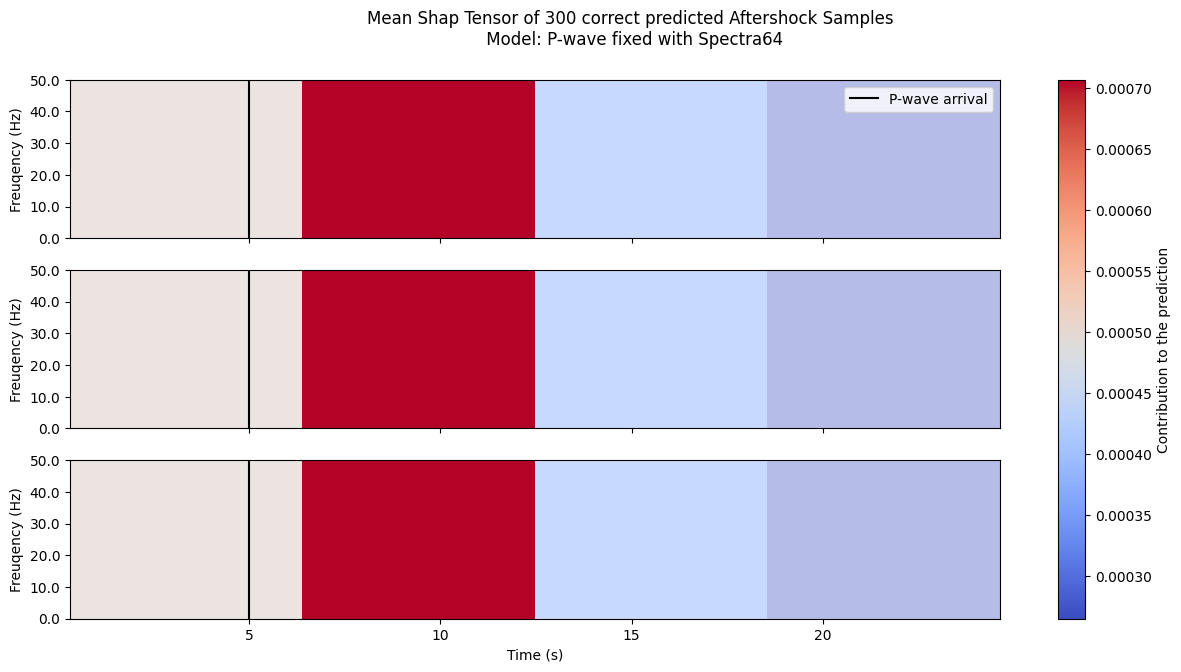

In [102]:
plot_shap(mean_shap_tensor, onechannel=True, background=None, spec_type="p64", mean=f"Mean Shap Tensor of 300 correct predicted Aftershock Samples \n Model: P-wave fixed with Spectra64")
plot_shap(mean_shap_tensor, onechannel=False, background=None, spec_type="p64", mean=f"Mean Shap Tensor of 300 correct predicted Aftershock Samples \n Model: P-wave fixed with Spectra64")

### Spectra32 Settings
$
\textbf{NPERSEG} = 32
$

$
\textbf{NOVERLAP} = \textbf{NPERSEG} * 0.5
$

In [103]:
model = CNN2D.load_from_checkpoint(best_model_p_32, input_dim=dim_p32, num_classes=2)
model.eval()
model.to(device)
print("Model loaded")

Model loaded


#### Foreshocks

In [104]:
dset_pre = SpectraDataset_p(os.path.join(data_path_32_p, "foreshock"), transform=transform_32, get_image_name=True)
dloader_pre = DataLoader(dset_pre, batch_size=30, shuffle=False)

In [105]:
mean_shap_tensor = compute_mean_shap_tensor(model, dloader_pre, dim_p32, max_evals = 10, masker_settings = "inpaint_telea", save_path = None)

Computing Mean SHAP Tensor: 100%|██████████| 10/10 [00:25<00:00,  2.53s/it]


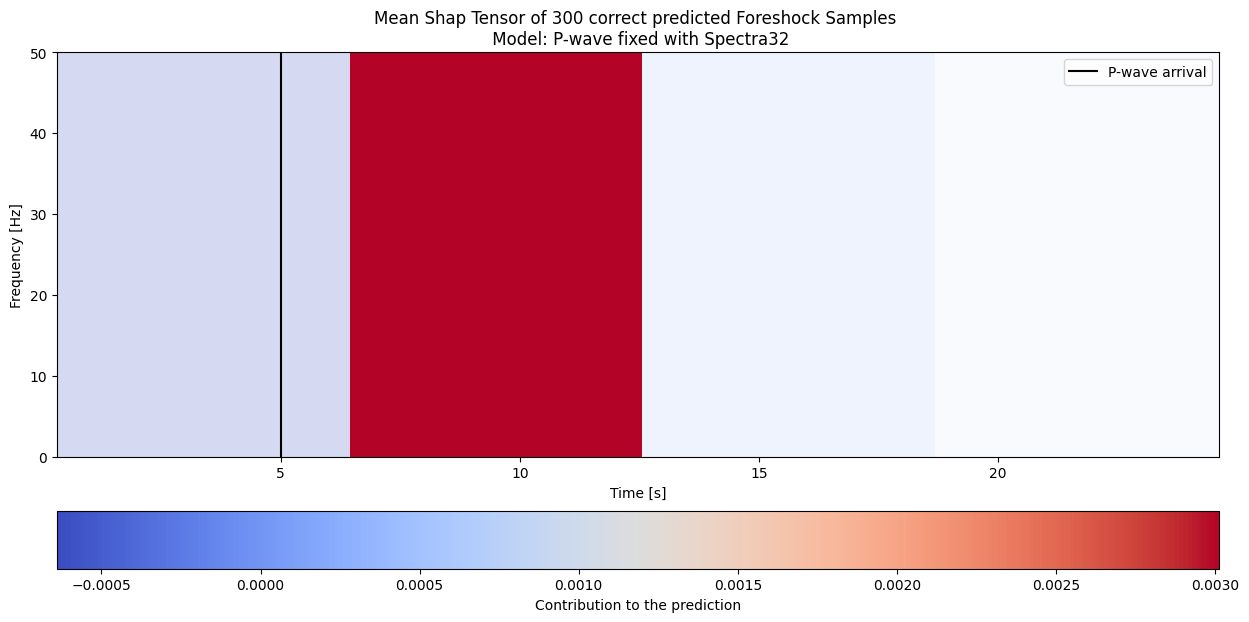

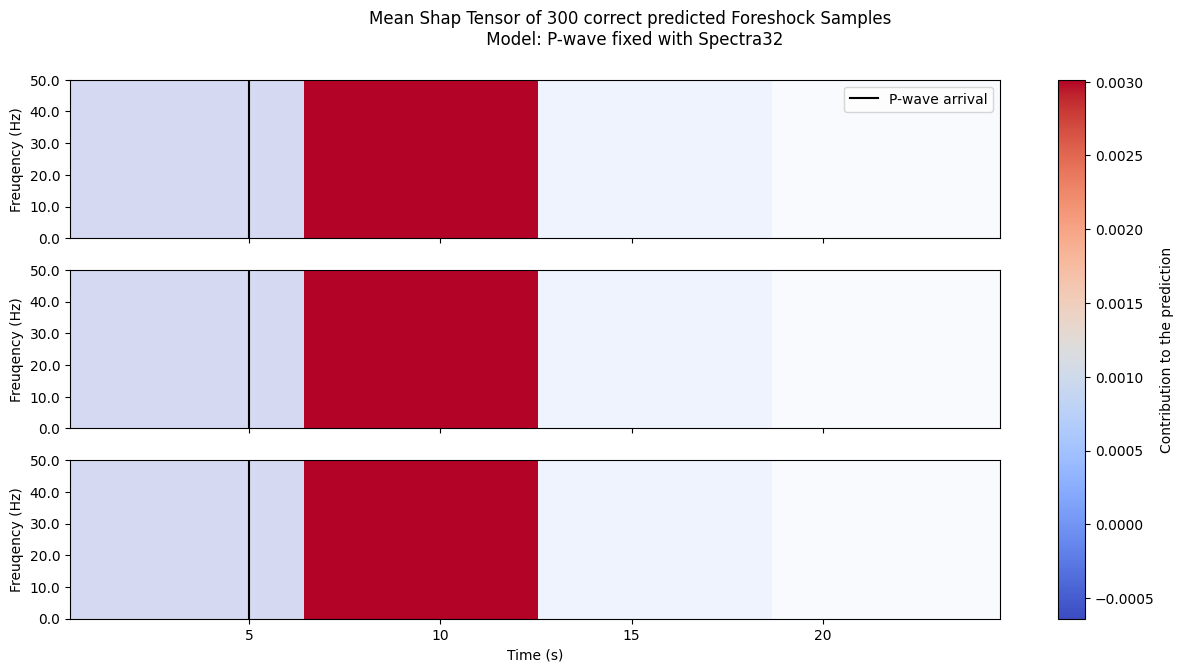

In [106]:
plot_shap(mean_shap_tensor, onechannel=True, background=None, spec_type="p32", mean=f"Mean Shap Tensor of 300 correct predicted Foreshock Samples \n Model: P-wave fixed with Spectra32")
plot_shap(mean_shap_tensor, onechannel=False, background=None, spec_type="p32", mean=f"Mean Shap Tensor of 300 correct predicted Foreshock Samples \n Model: P-wave fixed with Spectra32")

#### Aftershocks

In [107]:
dset_post = SpectraDataset_p(os.path.join(data_path_32_p, "aftershock"), transform=transform_32, get_image_name=True)
dloader_post = DataLoader(dset_post, batch_size=30, shuffle=False)

In [108]:
mean_shap_tensor = compute_mean_shap_tensor(model, dloader_post, dim_p32, max_evals = 10, masker_settings = "inpaint_telea", save_path = None)

Computing Mean SHAP Tensor: 100%|██████████| 10/10 [00:23<00:00,  2.39s/it]


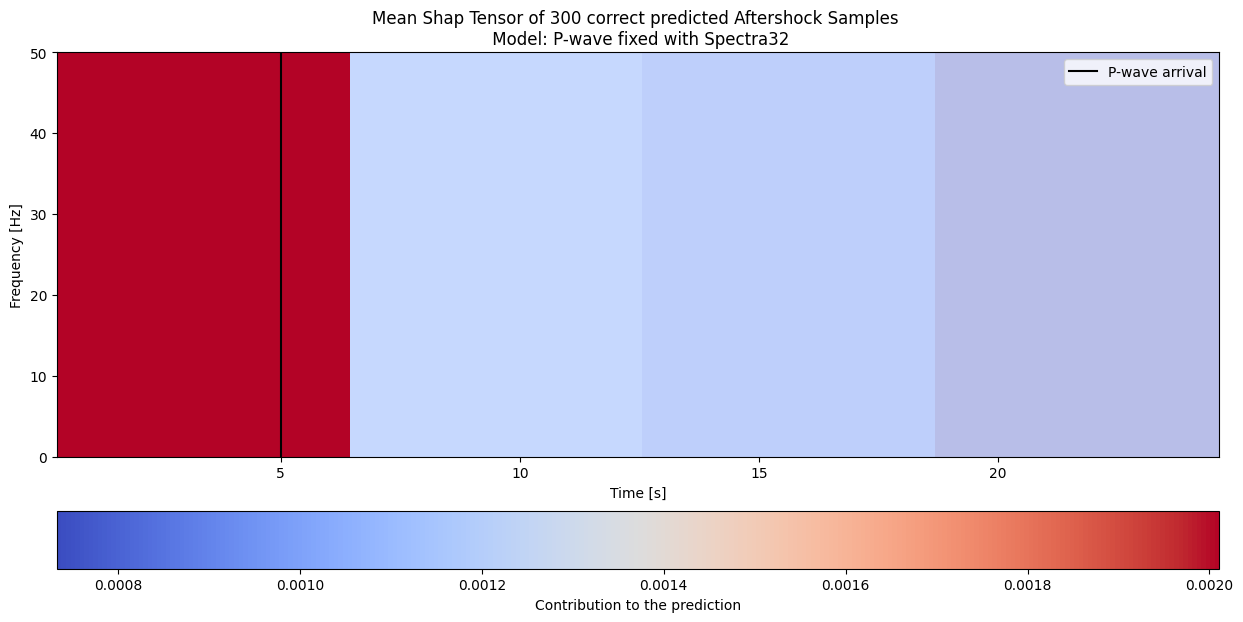

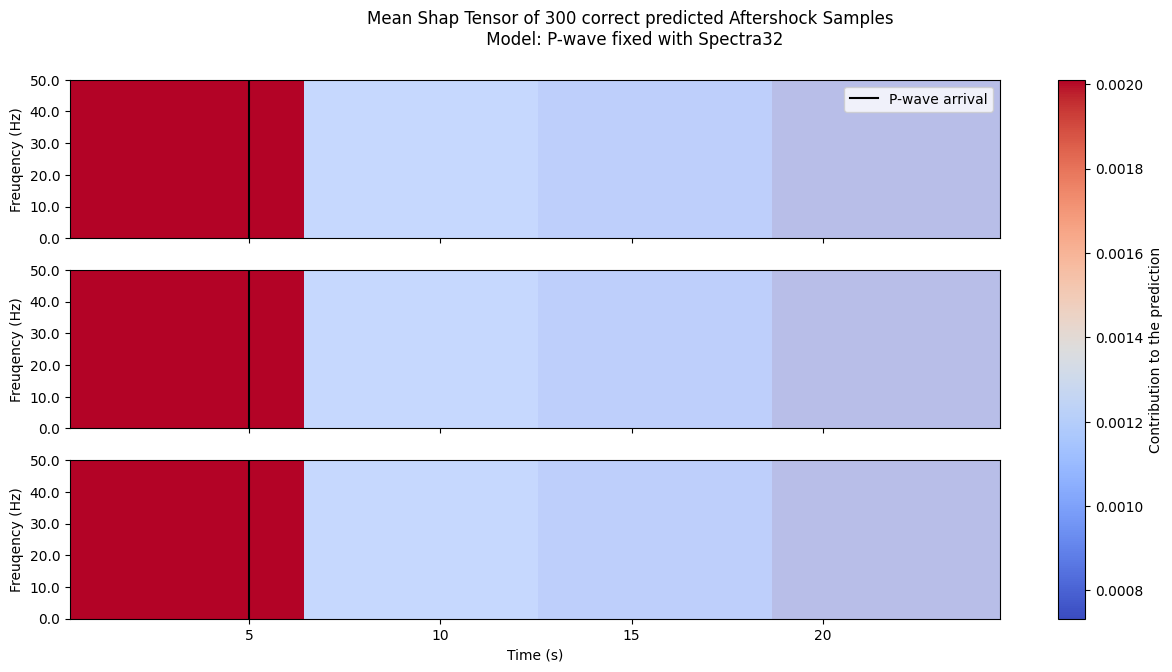

In [109]:
plot_shap(mean_shap_tensor, onechannel=True, background=None, spec_type="p32", mean=f"Mean Shap Tensor of 300 correct predicted Aftershock Samples \n Model: P-wave fixed with Spectra32")
plot_shap(mean_shap_tensor, onechannel=False, background=None, spec_type="p32", mean=f"Mean Shap Tensor of 300 correct predicted Aftershock Samples \n Model: P-wave fixed with Spectra32")

## Explainability on S-Wave fixed Spectrograms

### Spectra64 Settings

In [111]:
model = CNN2D.load_from_checkpoint(best_model_s_64, input_dim=dim_s64, num_classes=2)
model.eval()
model.to(device)
print("Model loaded")

Model loaded


#### Foreshocks

In [122]:
dset_pre = SpectraDataset_s(os.path.join(data_path_64_s, "foreshock"),meta_path=meta_path, transform=transform_64, get_image_name=True)
dloader_pre = DataLoader(dset_pre, batch_size=30, shuffle=False)

In [126]:
mean_shap_tensor = compute_mean_shap_tensor(model, dloader_pre, dim_s64, max_evals = 10, masker_settings = "inpaint_telea", save_path = None)

Computing Mean SHAP Tensor: 100%|██████████| 10/10 [00:49<00:00,  4.94s/it]


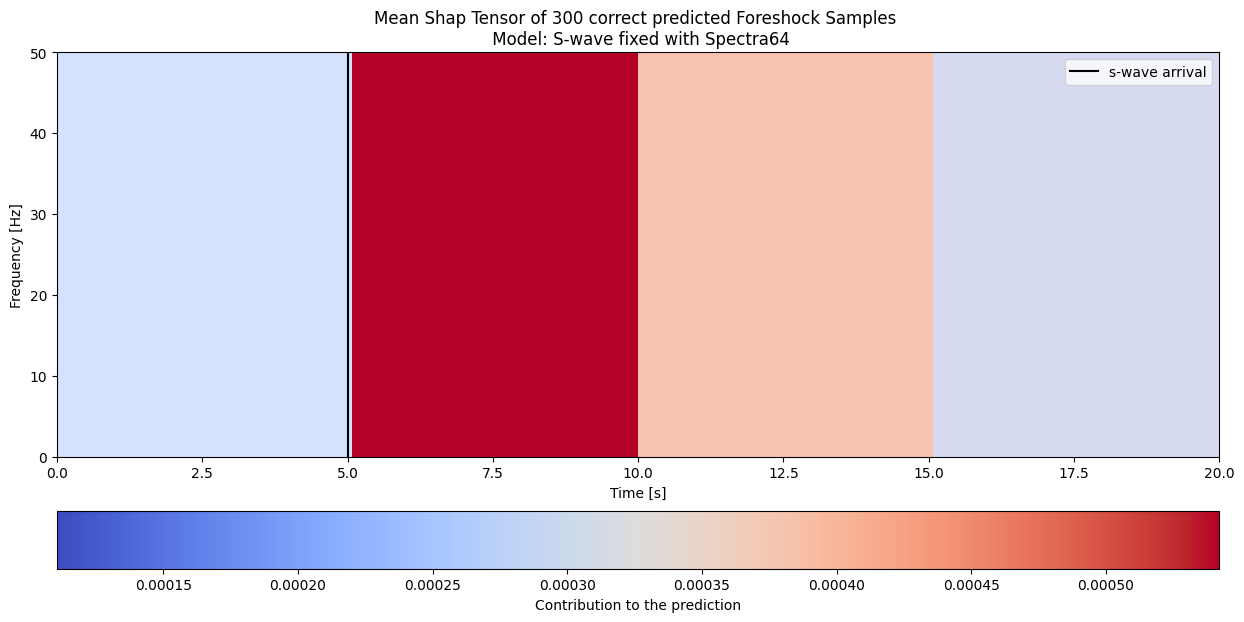

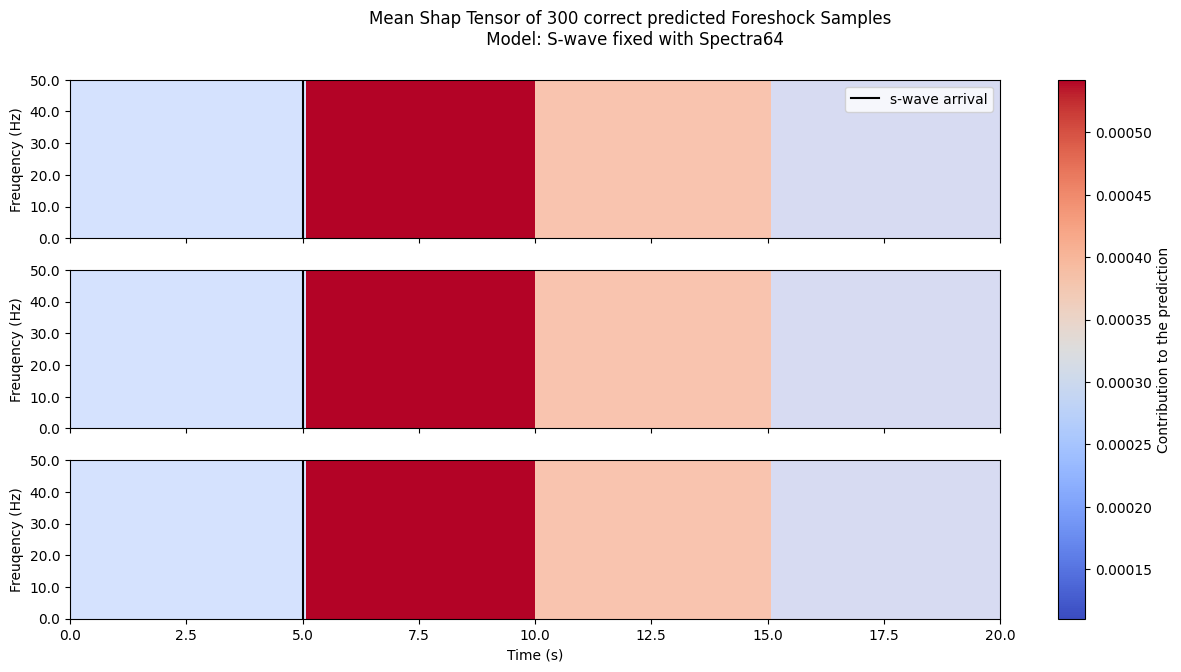

In [131]:
plot_shap(mean_shap_tensor, onechannel=True, background=None, spec_type="s64", mean=f"Mean Shap Tensor of 300 correct predicted Foreshock Samples \n Model: S-wave fixed with Spectra64")
plot_shap(mean_shap_tensor, onechannel=False, background=None, spec_type="s64", mean=f"Mean Shap Tensor of 300 correct predicted Foreshock Samples \n Model: S-wave fixed with Spectra64")

#### Aftershocks

In [133]:
dset_post = SpectraDataset_s(os.path.join(data_path_64_s, "aftershock"), meta_path = meta_path, transform=transform_64, get_image_name=True)
dloader_post = DataLoader(dset_post, batch_size=30, shuffle=False)

In [134]:
mean_shap_tensor = compute_mean_shap_tensor(model, dloader_post, dim_s64, max_evals = 10, masker_settings = "inpaint_telea", save_path = None)

Computing Mean SHAP Tensor: 100%|██████████| 10/10 [00:40<00:00,  4.02s/it]


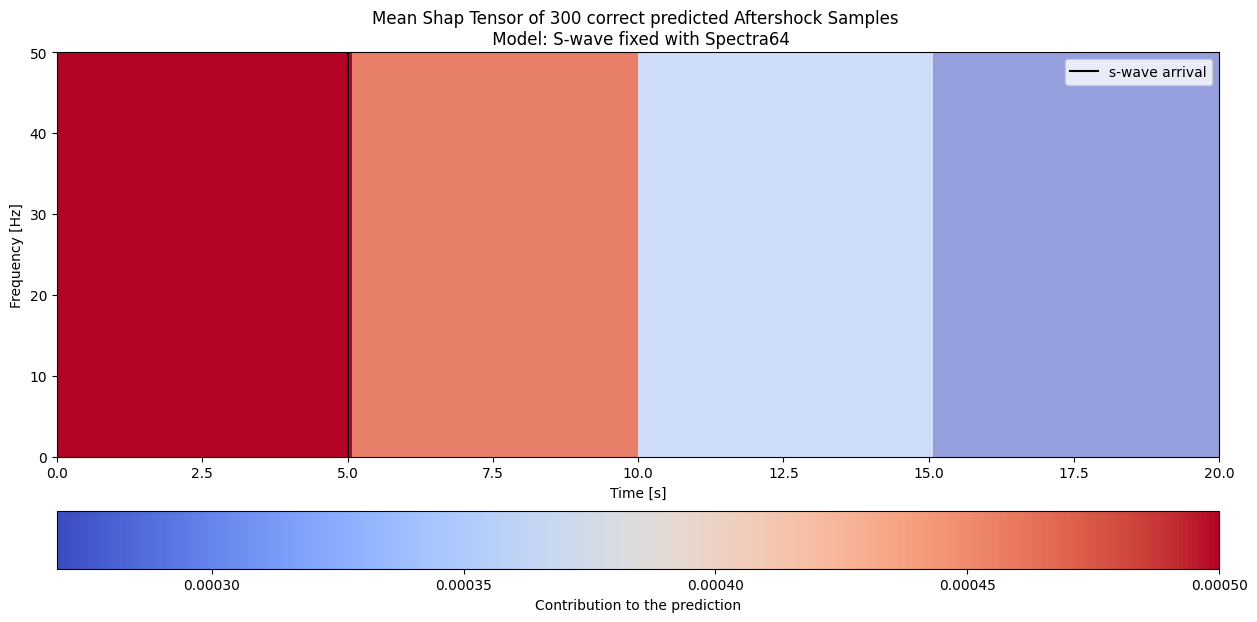

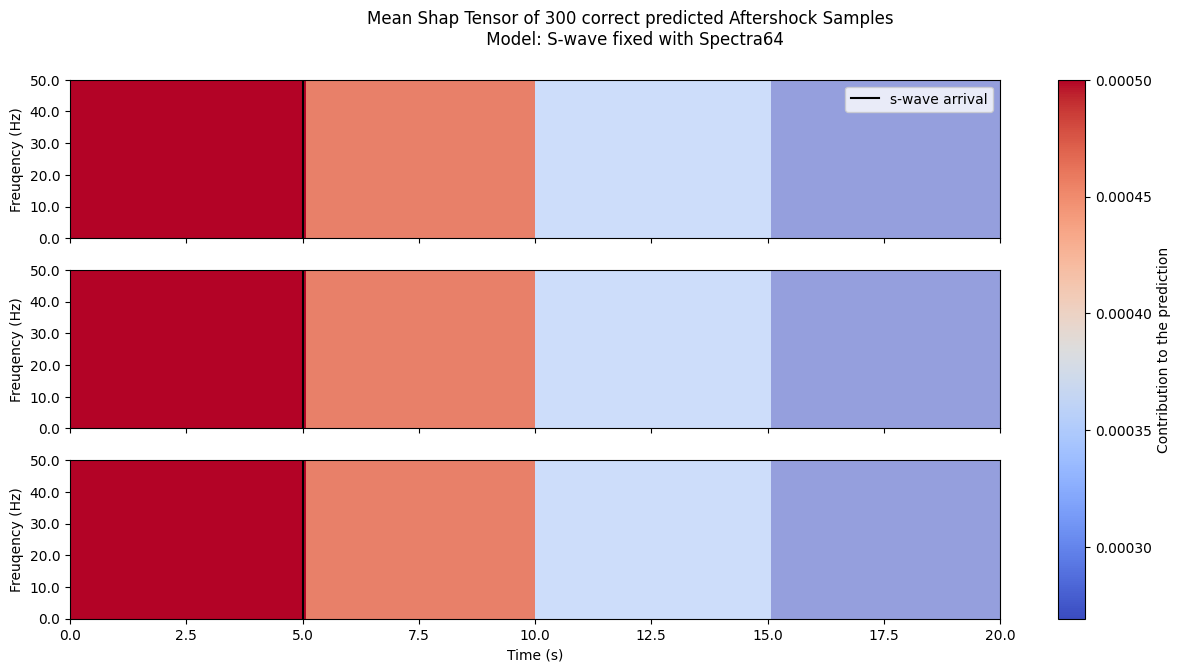

In [135]:
plot_shap(mean_shap_tensor, onechannel=True, background=None, spec_type="s64", mean=f"Mean Shap Tensor of 300 correct predicted Aftershock Samples \n Model: S-wave fixed with Spectra64")
plot_shap(mean_shap_tensor, onechannel=False, background=None, spec_type="s64", mean=f"Mean Shap Tensor of 300 correct predicted Aftershock Samples \n Model: S-wave fixed with Spectra64")

### Spectra32 Settings

In [137]:
model = CNN2D.load_from_checkpoint(best_model_s_32, input_dim=dim_s32, num_classes=2)
model.eval()
model.to(device)
print("Model loaded")

Model loaded


#### Foreshocks

In [138]:
dset_pre = SpectraDataset_s(os.path.join(data_path_32_s, "foreshock"), meta_path = meta_path, transform=transform_32, get_image_name=True)
dloader_pre = DataLoader(dset_pre, batch_size=30, shuffle=False)

In [139]:
mean_shap_tensor = compute_mean_shap_tensor(model, dloader_pre, dim_s32, max_evals = 10, masker_settings = "inpaint_telea", save_path = None)

Computing Mean SHAP Tensor: 100%|██████████| 10/10 [00:23<00:00,  2.33s/it]


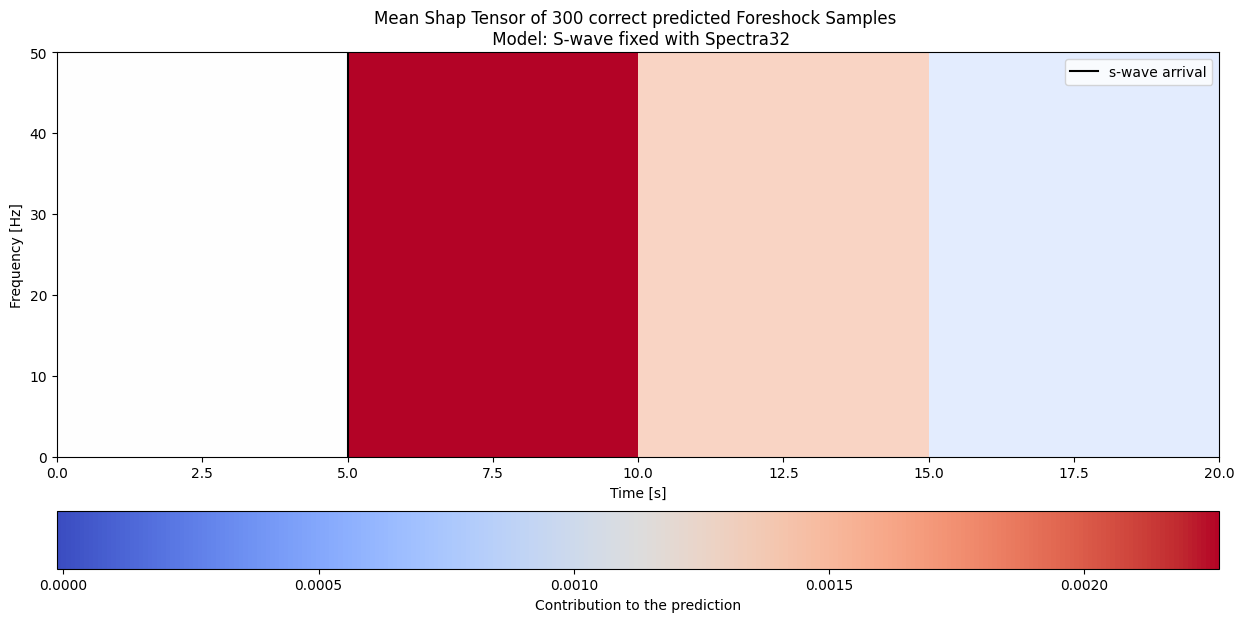

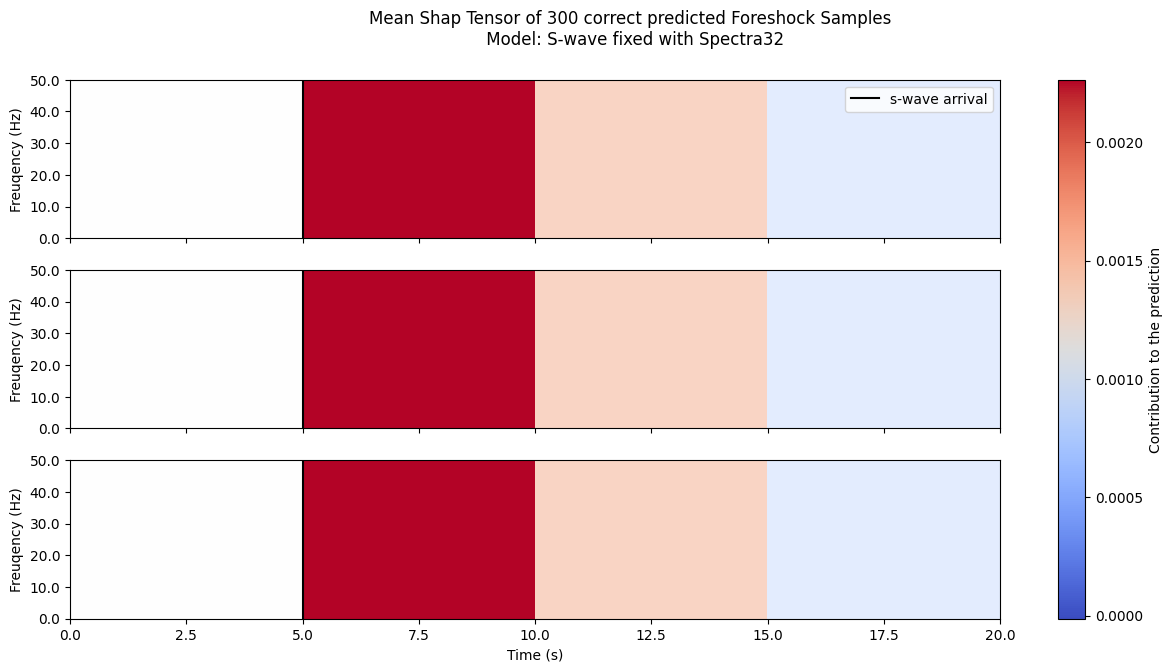

In [140]:
plot_shap(mean_shap_tensor, onechannel=True, background=None, spec_type="s32", mean=f"Mean Shap Tensor of 300 correct predicted Foreshock Samples \n Model: S-wave fixed with Spectra32")
plot_shap(mean_shap_tensor, onechannel=False, background=None, spec_type="s32", mean=f"Mean Shap Tensor of 300 correct predicted Foreshock Samples \n Model: S-wave fixed with Spectra32")

#### Aftershocks

In [141]:
dset_post = SpectraDataset_s(os.path.join(data_path_32_s, "aftershock"), meta_path=meta_path, transform=transform_32, get_image_name=True)
dloader_post = DataLoader(dset_post, batch_size=30, shuffle=False)

In [142]:
mean_shap_tensor = compute_mean_shap_tensor(model, dloader_post, dim_s32, max_evals = 10, masker_settings = "inpaint_telea", save_path = None)

Computing Mean SHAP Tensor: 100%|██████████| 10/10 [00:22<00:00,  2.26s/it]


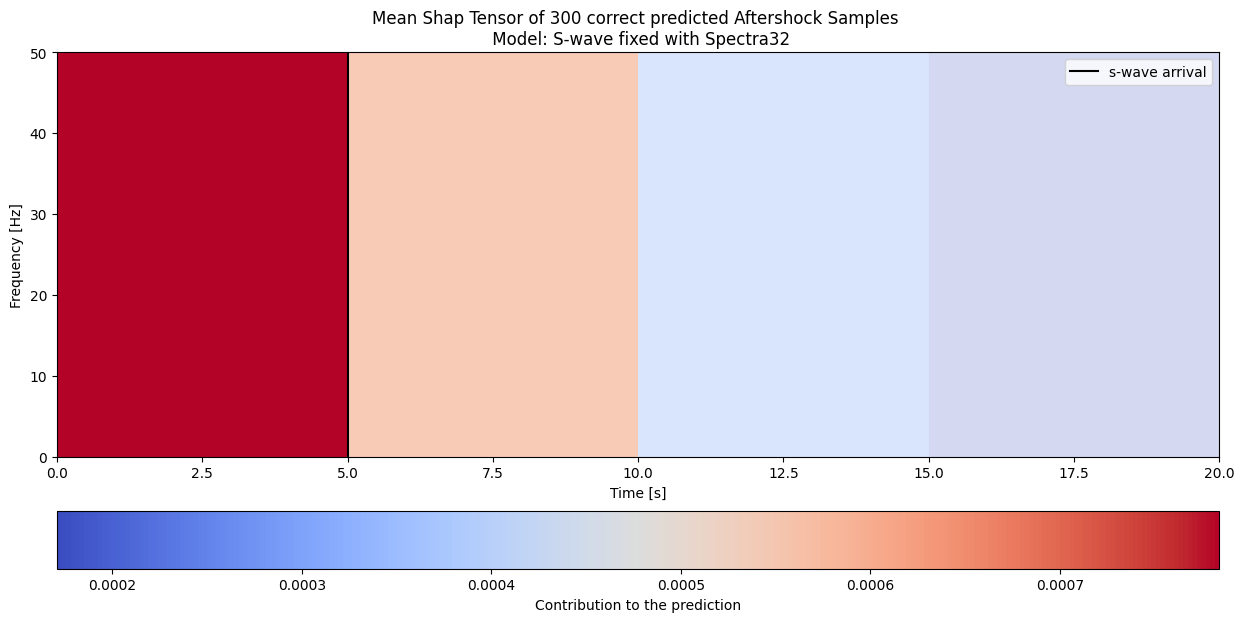

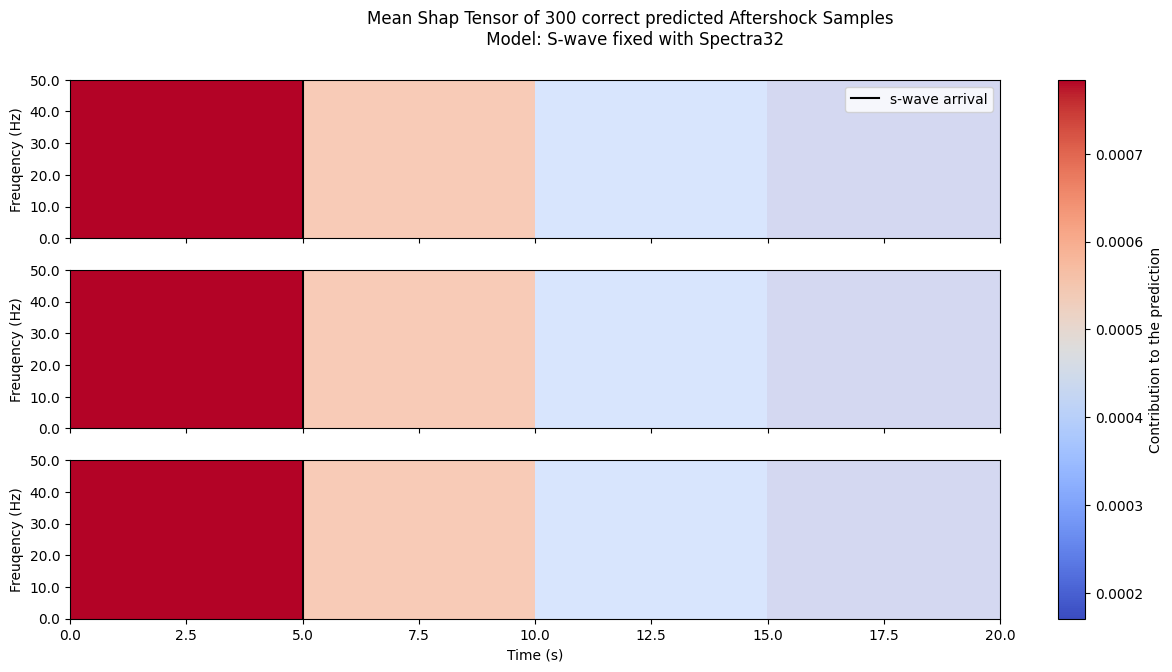

In [143]:
plot_shap(mean_shap_tensor, onechannel=True, background=None, spec_type="s32", mean=f"Mean Shap Tensor of 300 correct predicted Aftershock Samples \n Model: S-wave fixed with Spectra32")
plot_shap(mean_shap_tensor, onechannel=False, background=None, spec_type="s32", mean=f"Mean Shap Tensor of 300 correct predicted Aftershock Samples \n Model: S-wave fixed with Spectra32")